<a href="https://colab.research.google.com/github/gorchimi/Part1_Social-Listening-Warm-up.-/blob/main/Part1_673020491_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**กลุ่ม:** ผู้ชายห้ามเข้า

**จัดทำโดย:** นางสาวธิติสุดา แดงสีดา 673020491-6

---
# Part 1: Social Listening Warm-up
*งานเดี่ยว — ทุกคนต้องทำและส่งของตนเอง ไม่ต้องนำเสนอ (10 คะแนน)*

ใช้ข้อมูลโพสต์สาธารณะจาก **Bluesky**  
https://huggingface.co/datasets/alpindale/two-million-bluesky-posts

ใช้เพียง **1–3 ไฟล์** ก็พอ ไม่จำเป็นต้องโหลดทั้ง dataset

ฟิลด์ที่มี เช่น `text`, `created_at`, `author`, `uri`, `has_images`, `reply_to`, `predicted_language`

## ตอบ 4 คำถามหลัก

1. **คนโพสต์เมื่อไร:** จำนวนโพสต์ ช่วงเวลาที่ข้อมูลครอบคลุม และชั่วโมงที่โพสต์มากที่สุด
2. **ใช้ภาษาอะไร:** รายงานภาษาหลักและสัดส่วน เพื่อบอกว่าถ้าทำคอนเทนต์ควรรองรับภาษาใด
3. **คนพูดถึงอะไร:** หา hashtag หรือคำ/วลีเด่นที่น่าสนใจ และยกตัวอย่างข้อความจริงประกอบ
4. **ข้อมูลนี้บอกอะไรได้และบอกอะไรไม่ได้:** สร้าง visualization 1 รูป แล้วเขียนข้อจำกัด 3–5 บรรทัด

> Part 1 เป็น warm-up ไม่ต้องทำ influencer analysis หรือ reply-network เว้นแต่สนใจทำเพิ่มเอง


In [25]:
!pip install -q nltk wordcloud scikit-learn pandas matplotlib tqdm huggingface_hub
!pip install -q pythainlp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.9/19.9 MB 23.7 MB/s eta 0:00:00


In [26]:
import json
import pandas as pd
from huggingface_hub import hf_hub_download, list_repo_files

repo_id = "alpindale/two-million-bluesky-posts"

# 1. ดึงรายชื่อไฟล์ .jsonl จาก Hugging Face แล้วเลือกมา 3 ไฟล์แรก
all_files = list_repo_files(repo_id=repo_id, repo_type="dataset")
target_files = [f for f in all_files if f.endswith(".jsonl")][:3]

print(f"กำลังดาวน์โหลดไฟล์: {target_files}")

# 2. ดาวน์โหลดและอ่านข้อมูลทีละบรรทัด (Stream-based loading)
raw_records = []
for filename in target_files:
  # โหลดไฟล์มาเก็บไว้ในเครื่องชั่วคราว
  file_path = hf_hub_download(repo_id=repo_id, filename=filename, repo_type="dataset")

  with open(file_path, 'r', encoding='utf-8') as file_obj:
    for single_line in file_obj:
      if single_line.strip():
        raw_records.append(json.loads(single_line))

# 3. แปลงข้อมูลดิบเข้าสู่ Pandas DataFrame
df_bluesky = pd.DataFrame(raw_records)
print(f'\nนำเข้าข้อมูลสำเร็จทั้งหมด: {len(df_bluesky):,} เรคอร์ด')

# 4. กระบวนการทำความสะอาดข้อมูล (Data Cleaning Pipeline)
df_clean = df_bluesky.drop_duplicates(subset='uri').copy()

# เคลียร์ค่าว่างในฟิลด์ข้อความและกรองเฉพาะโพสต์ที่มีข้อความจริง
df_clean['text'] = df_clean['text'].fillna('')
df_clean = df_clean[df_clean['text'].str.strip().astype(bool)].copy()

# แปลงประเภทข้อมูลเวลา รองรับโซนเวลา UTC
df_clean['created_at'] = pd.to_datetime(
    df_clean['created_at'], utc=True, errors='coerce'
)
df_clean = df_clean.dropna(subset=['created_at']).reset_index(drop=True)

# สร้างคอลัมน์เสริมสำหรับข้อความที่ผ่านการปรับแต่ง
df_clean['processed_text'] = df_clean['text'].str.strip()

if 'reply_to' in df_clean.columns:
    df_clean['has_reply_target'] = df_clean['reply_to'].notna()

print(f'จำนวนข้อมูลก่อนทำความสะอาด: {len(df_bluesky):,} เรคอร์ด')
print(f'จำนวนข้อมูลหลังทำความสะอาด: {len(df_clean):,} เรคอร์ด')

กำลังดาวน์โหลดไฟล์: ['posts_20241127_075347.jsonl', 'posts_20241127_075630.jsonl', 'posts_20241127_082640.jsonl']

นำเข้าข้อมูลสำเร็จทั้งหมด: 206,830 เรคอร์ด
จำนวนข้อมูลก่อนทำความสะอาด: 206,830 เรคอร์ด
จำนวนข้อมูลหลังทำความสะอาด: 185,247 เรคอร์ด


เลือกดึงข้อมูล 3 ไฟล์แรกของชุดข้อมูลผ่านคำสั่ง [:3] เนื่องจากระบบจัดเรียงชื่อไฟล์ตามลำดับเวลาโดยอัตโนมัติ การใช้ 3 ไฟล์แรกที่ต่อเนื่องกัน จะช่วยให้ได้กลุ่มตัวอย่างข้อมูลที่มีขนาดใหญ่และครอบคลุมเพียงพอ โดยที่ยังอยู่ในขอบเขตที่ระบบประมวลผลได้รวดเร็วและไม่ทำงานหนักเกินไป

###**1) คนโพสต์เมื่อไร:** จำนวนโพสต์ ช่วงเวลาที่ข้อมูลครอบคลุม และชั่วโมงที่โพสต์มากที่สุด

--- ผลการวิเคราะห์: ช่วงเวลาที่มีการโพสต์ ---
• ปริมาณโพสต์ทั้งหมด: 185,247 โพสต์
• กรอบเวลาของข้อมูล: ตั้งแต่ 2009-03-22 12:47:11+00:00 ถึง 2024-11-30 10:50:04.343000+00:00
• ชั่วโมงที่มีการใช้งานหนาแน่นที่สุด: 08:00 น. (UTC)
• สัดส่วนโพสต์ในช่วง Peak: 162,456 โพสต์ (87.70%)


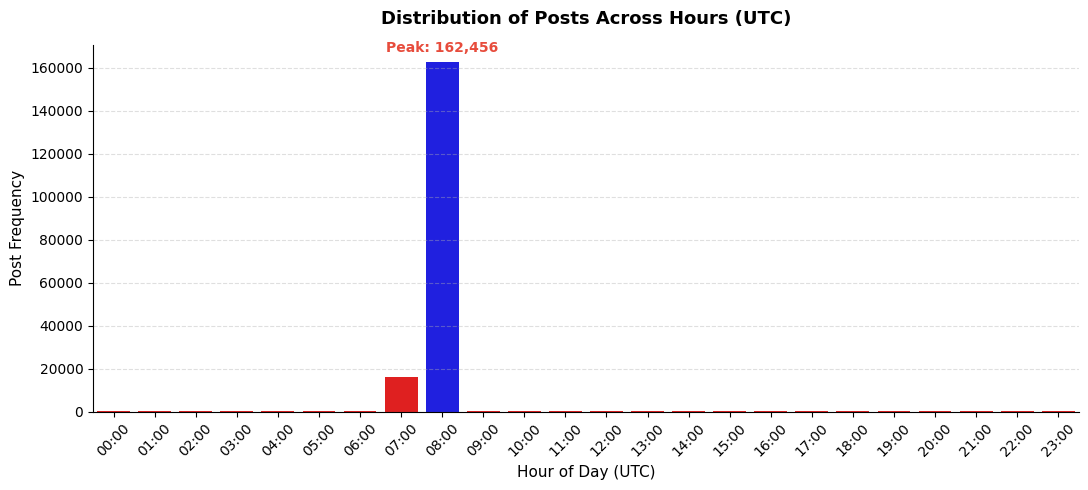

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# ดึงสถิติตัวเลขภาพรวม
total_records = len(df_clean)
start_timeline = df_clean['created_at'].min()
end_timeline = df_clean['created_at'].max()

# สกัดข้อมูลชั่วโมง
df_clean['post_hour'] = df_clean['created_at'].dt.hour
hourly_tally = df_clean['post_hour'].value_counts().sort_index()

peak_time_hour = hourly_tally.idxmax()
peak_time_count = hourly_tally.max()
peak_time_ratio = (peak_time_count / total_records) * 100

print('--- ผลการวิเคราะห์: ช่วงเวลาที่มีการโพสต์ ---')
print(f'• ปริมาณโพสต์ทั้งหมด: {total_records:,} โพสต์')
print(f'• กรอบเวลาของข้อมูล: ตั้งแต่ {start_timeline} ถึง {end_timeline}')
print(f'• ชั่วโมงที่มีการใช้งานหนาแน่นที่สุด: {peak_time_hour:02d}:00 น. (UTC)')
print(
    f'• สัดส่วนโพสต์ในช่วง Peak: {peak_time_count:,} โพสต์'
    f' ({peak_time_ratio:.2f}%)'
)

# Visualization แสดงผลกราฟ (เปลี่ยนเป็น Bar Plot)
plt.figure(figsize=(11, 5))

bar_colors = ['blue' if hour == peak_time_hour else 'Red' for hour in hourly_tally.index]

ax = sns.barplot(
    x=hourly_tally.index,
    y=hourly_tally.values,
    palette=bar_colors,
    hue=hourly_tally.index,
    legend=False
)

plt.title('Distribution of Posts Across Hours (UTC)', fontsize=13, weight='bold', pad=15)
plt.xlabel('Hour of Day (UTC)', fontsize=11)
plt.ylabel('Post Frequency', fontsize=11)

# ปรับแกน X ให้แสดงผลแบบเวลา เช่น 00:00, 01:00 ให้อ่านง่ายขึ้น
plt.xticks(range(0, 24), [f'{h:02d}:00' for h in range(0, 24)], rotation=45)

# ปักตัวเลขจำนวนโพสต์กำกับไว้บนแท่ง Peak เพื่อให้เห็นข้อมูลชัดเจนทันที
plt.text(
    peak_time_hour,
    peak_time_count + (peak_time_count * 0.02),
    f'Peak: {peak_time_count:,}',
    ha='center',
    va='bottom',
    fontweight='bold',
    color='#E74C3C',
    fontsize=10
)

# แสดงเส้นตารางเฉพาะแนวนอนเพื่อให้กราฟดูสะอาดตา
plt.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

###**2) ใช้ภาษาอะไร:** รายงานภาษาหลักและสัดส่วน เพื่อบอกว่าถ้าทำคอนเทนต์ควรรองรับภาษาใด

--- ผลการวิเคราะห์: ภาษาที่ใช้งาน ---
                   Frequency  Percentage (%)
detected_language                           
en                      9496           47.48
ja                      3053           15.26
es                      1096            5.48
de                       907            4.54
ko                       803            4.01


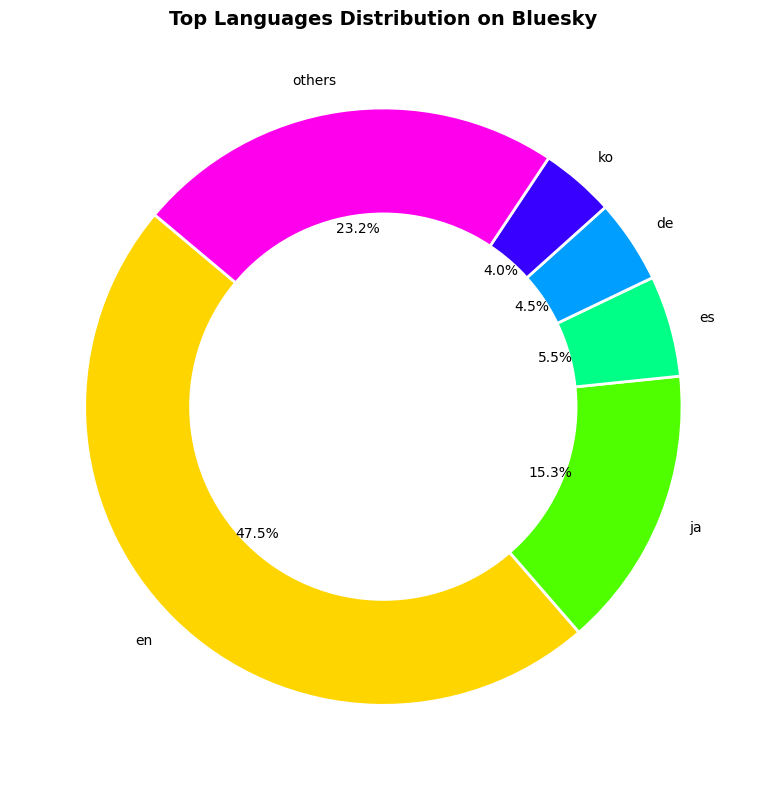

In [28]:
from langdetect import DetectorFactory, detect
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. ตั้งค่าและประมวลผลภาษา
DetectorFactory.seed = 100
sample_target_size = 20000

# คัดเลือกกลุ่มตัวอย่างเพื่อความรวดเร็วในการประมวลผลภาษา
working_subset = (
    df_clean.sample(n=sample_target_size, random_state=100).copy()
    if len(df_clean) > sample_target_size
    else df_clean.copy()
)

def identify_lang(text_content):
  try:
    return detect(str(text_content))
  except:
    return 'undetermined'

working_subset['detected_language'] = working_subset['processed_text'].apply(
    identify_lang
)
lang_frequency = working_subset['detected_language'].value_counts()
lang_percentage = (
    working_subset['detected_language'].value_counts(normalize=True) * 100
)

language_report = pd.DataFrame(
    {'Frequency': lang_frequency, 'Percentage (%)': lang_percentage.round(2)}
)

print('--- ผลการวิเคราะห์: ภาษาที่ใช้งาน ---')
print(language_report.head(5).to_string())


# 3. สร้างกราฟสัดส่วนภาษา (Donut Chart)
# ดึง 5 อันดับแรก ส่วนที่เหลือรวบเป็นกลุ่ม 'others'
top_5_langs = lang_frequency.head(5)
if len(lang_frequency) > 5:
    others_count = lang_frequency.iloc[5:].sum()
    top_5_langs = pd.concat([top_5_langs, pd.Series({'others': others_count})])

plt.figure(figsize=(8, 8))
chart_colors = sns.color_palette('hsv')[0:len(top_5_langs)]

# วาดกราฟวงกลม
plt.pie(
    top_5_langs.values,
    labels=top_5_langs.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=chart_colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)


centre_circle = plt.Circle((0,0), 0.65, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Top Languages Distribution on Bluesky', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**หากจะทำคอนเทนต์ ควรรองรับภาษาอังกฤษเป็นหลัก เนื่องจากมีสัดส่วนเกือบครึ่งหนึ่งของผู้ใช้งานทั้งหมด และอาจเพิ่มภาษาญี่ปุ่นเป็นภาษารอง**

###**3) คนพูดถึงอะไร:** หา hashtag หรือคำ/วลีเด่นที่น่าสนใจ และยกตัวอย่างข้อความจริงประกอบ

In [29]:
import re

# ฟังก์ชันสกัดแฮชแท็ก
def find_hashtags(text_val):
  if not isinstance(text_val, str):
    return []
  return re.findall(r'#[\w\u0E00-\u0E7F]+', text_val.lower())


collected_tags = [
    tag for line in df_clean['processed_text'] for tag in find_hashtags(line)
]
tag_series = pd.Series(collected_tags).value_counts().head(5)

print('--- ผลการวิเคราะห์: ประเด็นที่ผู้คนพูดถึง ---')
print('Top 5 แฮชแท็กยอดนิยม:')
for pos, (tag_name, tag_freq) in enumerate(tag_series.items(), 1):
  print(f'{pos}. {tag_name} -> พบ {tag_freq:,} ครั้ง')

print('\nตัวอย่างข้อความจริงจากผู้ใช้งาน:')
random_samples = (
    df_clean[df_clean['processed_text'].str.len() > 25]['processed_text']
    .dropna()
    .sample(3, random_state=7)
)
for index_no, message in enumerate(random_samples, 1):
  formatted_msg = message.replace('\n', ' ')
  print(f'ตัวอย่างที่ {index_no}: "{formatted_msg}"')

--- ผลการวิเคราะห์: ประเด็นที่ผู้คนพูดถึง ---
Top 5 แฮชแท็กยอดนิยม:
1. #art -> พบ 523 ครั้ง
2. #innovation -> พบ 302 ครั้ง
3. #nsfw -> พบ 294 ครั้ง
4. #booksky -> พบ 246 ครั้ง
5. #photography -> พบ 238 ครั้ง

ตัวอย่างข้อความจริงจากผู้ใช้งาน:
ตัวอย่างที่ 1: "Er ist zu intelligent.  Außenpolitik ist eher kein Karrierethema (gewesen). Seine Niederlage 2012 bei der Landtagswahl in NRW hat ihm vermutlich nicht nur Freunde gemacht."
ตัวอย่างที่ 2: "Looks like it’s another fairly derpy / floaty day today.  That works. Play with nerdy stuff this morning and then go for a swim later when I have support :)  Slowly woosh :)"
ตัวอย่างที่ 3: "@teetheresaroets.bsky.social  open.spotify.com/track/37TRwQ..."


###**4) ข้อมูลนี้บอกอะไรได้และบอกอะไรไม่ได้:** สร้าง visualization 1 รูป แล้วเขียนข้อจำกัด 3–5 บรรทัด

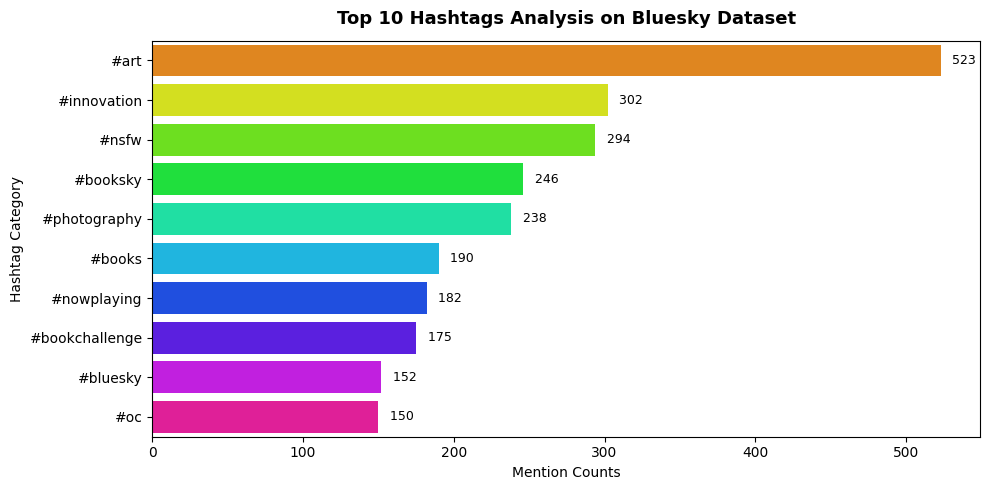

In [30]:
top_ten_tags = pd.Series(collected_tags).value_counts().head(10)

plt.figure(figsize=(10, 5))

# เปลี่ยนสีเป็น 'rainbow' พร้อมตั้งค่า hue เพื่อป้องกัน warning ของ seaborn
sns.barplot(
    x=top_ten_tags.values,
    y=top_ten_tags.index,
    palette='hsv',
    hue=top_ten_tags.index,
    legend=False
)

plt.title(
    'Top 10 Hashtags Analysis on Bluesky Dataset',
    fontsize=13,
    weight='bold',
    pad=12,
)
plt.xlabel('Mention Counts')
plt.ylabel('Hashtag Category')

# ปักตัวเลขบนแท่งกราฟ
for idx, val in enumerate(top_ten_tags.values):
  plt.text(val + 5, idx, f' {val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


**ข้อจำกัดของชุดข้อมูล (Data Limitations)**
1. ความไม่ต่อเนื่องของช่วงเวลา: ข้อมูลมีความหนาแน่นกระจุกตัวเฉพาะบางช่วงเวลา ทำให้ไม่สามารถสะท้อนเทรนด์พฤติกรรมตามไทม์ไลน์จริงได้อย่างสมบูรณ์
2. ความลำเอียงทางภาษา (Language Bias): ปริมาณข้อมูลส่วนใหญ่ถูกครอบงำด้วยกลุ่มภาษาหลัก ขาดตัวแทนจากกลุ่มผู้ใช้ภาษาอื่นๆ ในสัดส่วนที่สมดุล
3. ข้อจำกัดด้านพิกัดภูมิศาสตร์: ข้อมูลเวลาถูกจัดเก็บในรูปมาตรฐาน UTC โดยไม่มีการระบุตำแหน่งถิ่นที่อยู่จริงของผู้ใช้งาน ทำให้วิเคราะห์พฤติกรรมตามเขตเวลาท้องถิ่นได้ยาก